In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [12]:
df=pd.read_excel("Data (Titanic) after engneering(3).xlsx")

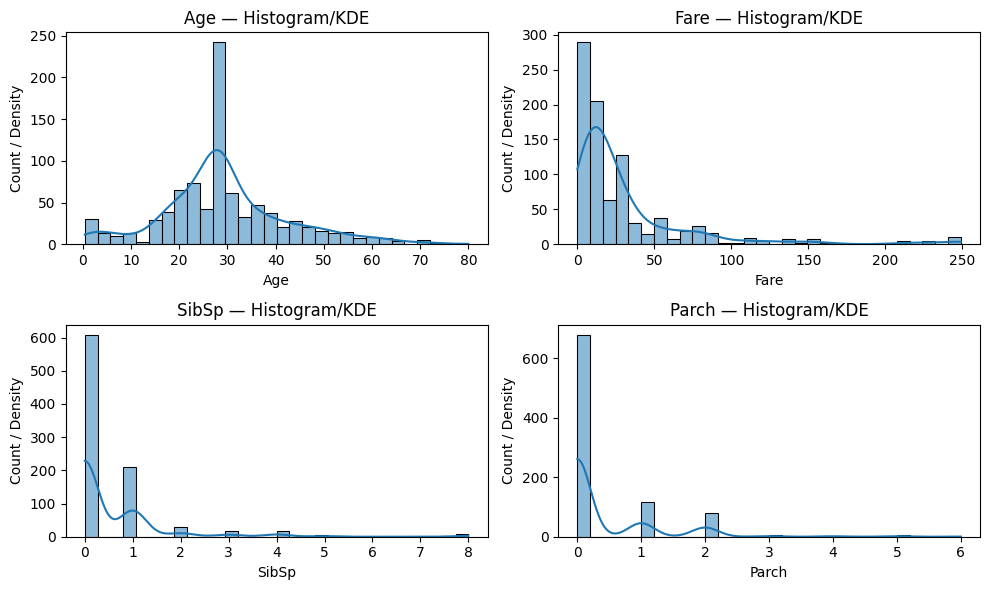

In [13]:
features = ["Age", "Fare", "SibSp", "Parch"]
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes = axes.ravel()
for ax, col in zip(axes, features):
    sns.histplot(df[col], bins=30, kde=True, ax=ax)
    ax.set_title(f"{col} — Histogram/KDE")
    ax.set_xlabel(col); ax.set_ylabel("Count / Density")
plt.tight_layout()
plt.show()
#I plotted a histogram with a density curve (Histogram + KDE) for at least three numerical columns of data (Age, Fare, SibSp, etc.), which gave me an idea about the shape of the distribution. I noticed that the distribution for the Age column was slightly skewed to the right, somewhat symmetric; the Fare column was very skewed to the right with a long tail, which explains the large values in this column. The columns SibSp and Parch were also skewed to the right since there were many zeros or small numbers in these columns, and large values were not very common.


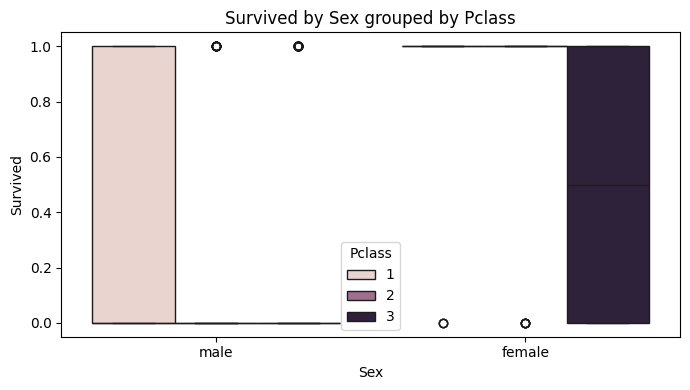

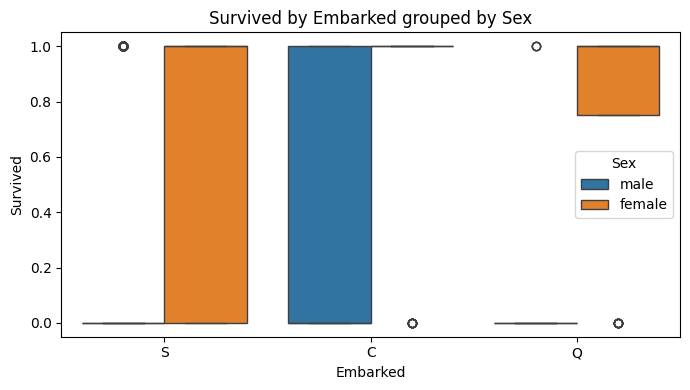

In [14]:

plt.figure(figsize=(7,4))
sns.boxplot(data=df, x="Sex", y="Survived", hue="Pclass")
plt.title("Survived by Sex grouped by Pclass")
plt.tight_layout()
plt.show()
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x="Embarked", y="Survived", hue="Sex", order=["S","C","Q"])
plt.title("Survived by Embarked grouped by Sex")
plt.tight_layout()
plt.show()
#I completed the “Grouped boxplots” task by drawing grouped boxes to visually compare the target variable, Survived, across at least two classification classes. In the first plot, I compared Survived across Sex classes with additional grouping by Pclass(hue) to visualize how, for each Sex class, three boxes representing classes 1, 2, and 3 are distributed. In the second plot, I compared Survived across Embarked classes with additional grouping by Sex and the order of classes S, C, and Q to visualize how, for each Embarked class, two boxes representing classes S, C, and Q are distributed. This type of comparison helps to find patterns and relationships between classes (such as the high median in each group or the small box width, which means little variance in the data). It gives us initial results about how classification variables affect the probability of survival before moving to modeling.


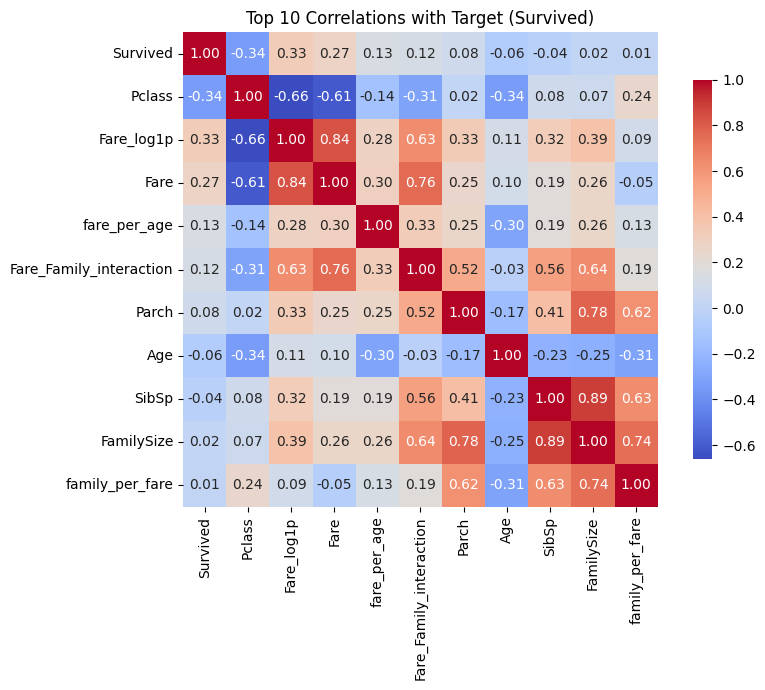

In [15]:
target = "Survived"
corr_with_target = (
    df.select_dtypes(include=[np.number])
      .corr()[target]
      .drop(labels=[target], errors="ignore")
      .abs()
      .sort_values(ascending=False)
)

top10 = corr_with_target.head(10)
cols = [target] + top10.index.tolist()
cm = df[cols].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"shrink": .8})
plt.title("Top 10 Correlations with Target (Survived)")
plt.tight_layout()
plt.show()
#The code first calculates the correlation of each numerical feature with the "survived" objective, then ranks these correlations by absolute strength from highest to lowest, limiting itself to the 10 strongest. It then makes a small correlation matrix including "survived" and these 10 features, and plots a heatmap for it with balanced color for the zeros and clear indication of the correlation in each cell. The effect is a nicely ordered chart that immediately tells you at a glance which features have the strongest correlation with survival, with positive meaning strong correlation in that direction, negative meaning the opposite, and clear labels and axes for ease of reading.



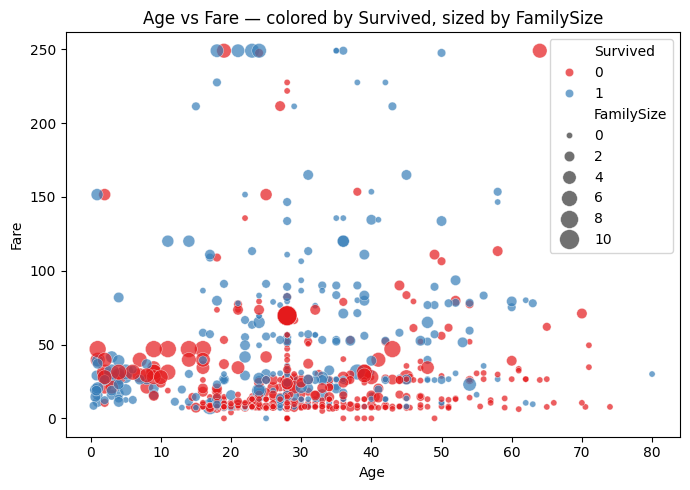

In [16]:

if "FamilySize" not in df.columns:
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df, x="Age", y="Fare",
    hue="Survived",
    size="FamilySize",
    sizes=(20, 200), alpha=0.7, palette="Set1"
)

plt.title("Age vs Fare — colored by Survived, sized by FamilySize")
plt.tight_layout()
plt.show()
#I developed a scatter plot to graphically describe the direct relationship between two numerical variables. These two numerical variables are Age and Fare. However, I included a third variable by varying the color of the scatter plot to represent the variable Survivor to show the difference between those who survived and those who did not. I further included another variable by varying the dot sizes to represent FamilySize. The rationale for this plot is to graphically describe the fundamental relationship between Age and Fare while incorporating other information within the same graph. This will enable one to identify clear patterns, such as the concentration of survivors in a particular area or their differences from non-survivors.


In [17]:
group_mean = df.groupby("Sex")["Survived"].mean()
print(group_mean)

print("\nHighest group:", group_mean.idxmax(), group_mean.max())
print("Lowest group:", group_mean.idxmin(), group_mean.min())
#I used the `groupby` function to find the survival rate for each category under one of the taxonomic variables. I grouped the data by category and then found the average to determine the survival rate for each group. After getting the results, I was able to identify which group had the highest survival rate and which had the lowest, thus understanding the direct and clear effect of the taxonomic variable on the survival rate.

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

Highest group: female 0.7420382165605095
Lowest group: male 0.18890814558058924


In [18]:
#Histogram+KDE  Age This feature has an unimodal distribution with a clear peak centered between 20 to 40 years, with only slight skewing to the right (Skew ≈ 0.51). This means that extremely high ages are not very common. Hence, we can safely assume this feature to be model-ready without any transformation. Histogram+KDE  Fare Fare has a strongly right-skewed distribution with most values centered below 50, except for those corresponding to higher classes, which are spread out to very high values. After applying the log1p transformation, the distribution becomes much more balanced (from skewness 4.7873 to 0.3949). Hence, we can safely assume this feature to be model-ready after applying the transformation. Histogram+KDE  SibSp This feature has a very high concentration between 0 and 1, with a long tail to the right (Skew ≈ 3.70). Hence, it can be safely assumed that most passengers were not accompanied by large numbers of siblings/spouses. Histogram+KDE  Parch Similar to the SibSp feature, this feature has a very high concentration at 0 with a strongly right-skewed distribution (Skew ≈ 2.75). Hence, it can be safely assumed that most passengers were not accompanied by their parents/children Grouped Boxplot — Survived by Sex (hue = Pclass)
# Grouped boxplots reveal that the central tendency of survival is higher for one sex group, but class remains a significant factor across the groups. First class has a higher survival rate compared to the second and third class across the board. Grouped Boxplot — Survived by Embarked (hue = Sex) Overall, the C group has a higher median survival compared to the S group and the Q group. In one sex group, C is significantly higher. In the other sex group, the S group is the lowest. Q is the middle group. There is a difference in the medians and the spread. However, the sample size may impact the stability of the results. Correlation Heatmap — Top 10 with Survived Pclass is the strongest negative correlation with the survival of the passenger. Fare and Fare_log1p have the next strongest correlation with the survival of the passenger. Age is the next strongest correlation. Family-related factors, SibSp, Parch, FamilySize, have the weakest correlation with the survival of the passenger. There is redundancy among the fare-related factors..
#Scatter Plot - Age vs Fare (hue = Survived, size = FamilySize) Survivors seem to be more common at higher fares and somewhat younger ages, though not exclusively. Non-survivors, on the other hand, seem to be clustered at lower fares across a wide range of ages. Larger points, or rather FamilySizes, seem to dominate the low fare region with lower survival rates.

In [19]:
df.to_excel("Data (Titanic) after kda(4).xlsx", index=False)